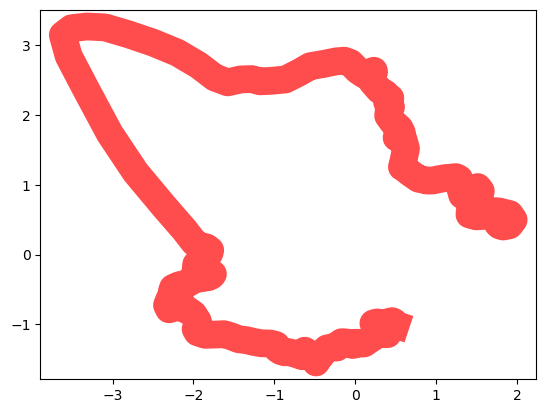

In [34]:
# Procrustes alignment and PCA sorting cross-validation by Python

import numpy as np
import scipy.io
import scipy.stats
import scipy.spatial
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn import decomposition
import pandas


def generate_continuous_data(raw_data, event, trial, padding):
    zs_data = scipy.stats.zscore(raw_data, axis=1)
    data = zs_data[:, round(event[trial[0]])-padding[0]:round(event[trial[1]])+padding[1]] 
    
    event_index = []
    for i in range(trial[0], trial[1]+1):
        event_index.append(round(event[i])-(round(event[trial[0]])-padding[0]))
    
    data = np.array(data)
    event_index = np.array(event_index)

    # Substract delay
    delay = 0.09
    event_index_new = []
    for i,e in enumerate(event_index):
        event_index_new.append(round(e+i*delay))
    event_index = event_index_new

    return data, event_index


# Generate neural data
path = 'E:/CK-87-Data/2023-04-06/'
Trace_Data_file = path+'2023-04-06_matlab.mat'
Trace_Data = scipy.io.loadmat(Trace_Data_file)['trace']
Trial_idx_file = path+'Trial_idx1.mat'
Trial_idx = scipy.io.loadmat(Trial_idx_file)['Trial_idx1']
door_open = Trial_idx[:,1]

Deconvolved_Data = scipy.io.loadmat(Trace_Data_file)['s_diff']

continuous_data, door_open_index = generate_continuous_data(Deconvolved_Data, door_open, [0,len(door_open)-1], [100,200])

# Smooth
continuous_data = gaussian_filter1d(continuous_data, 1, axis = 1)

reducer = decomposition.PCA(10)
embeddings = reducer.fit_transform(continuous_data.T)

loadings = reducer.components_

phase = np.arctan2(
    loadings[1, :],   # PC2 loading
    loadings[0, :]    # PC1 loading
)

pre=100
post=100
trial_averaged_embedding = []
for e in door_open_index:
    single_trial_embedding = embedding[e-pre:e+post]
    trial_averaged_embedding.append(single_trial_embedding)

trial_averaged_template = np.average(trial_averaged_embedding,axis=0)
plt.plot(trial_averaged_template[:,0],trial_averaged_template[:,1],linewidth=20,alpha=0.7,c='red')
plt.show()


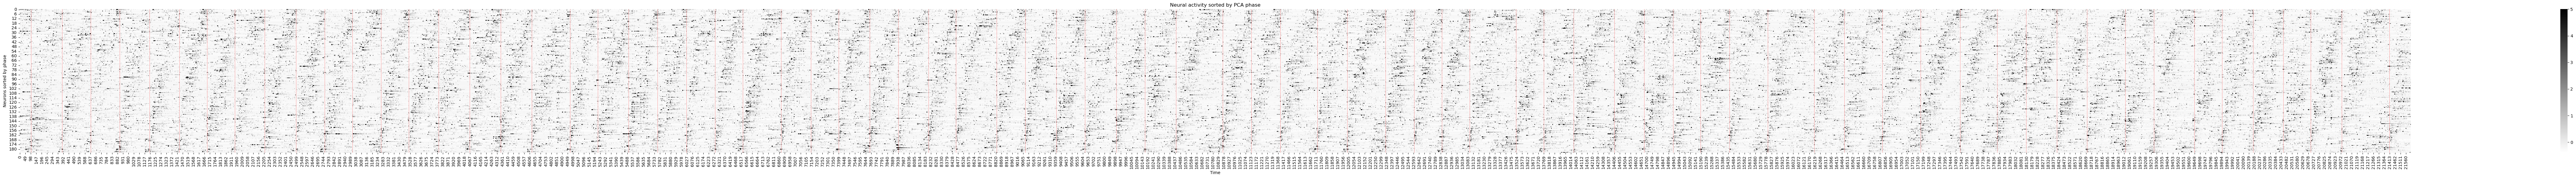

In [35]:
import seaborn as sns
sort_idx = np.argsort(phase)

sorted_data = continuous_data[sort_idx, :]

# --------------------------------------------------
# Plot sorted neurons
# --------------------------------------------------
plt.figure(figsize=(100, 6))
sns.heatmap(sorted_data, cmap="gray_r", cbar=True,vmax=5)

for e in door_open_index:
    plt.axvline(e, color="red", linestyle="--", linewidth=0.4)

plt.xlabel("Time")
plt.ylabel("Neurons sorted by phase")
plt.title("Neural activity sorted by PCA phase")
plt.tight_layout()
plt.show()

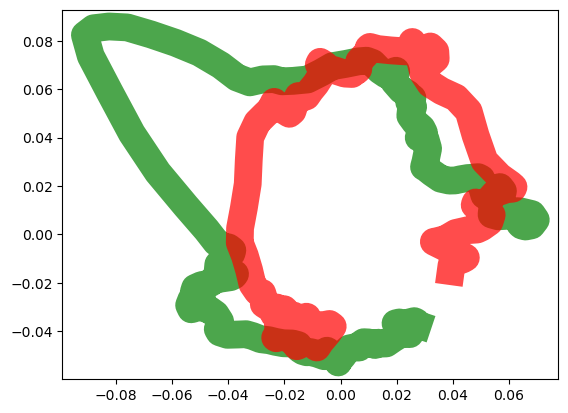

E:/CK-87-data/2023-03-21/
0.33335836081876713


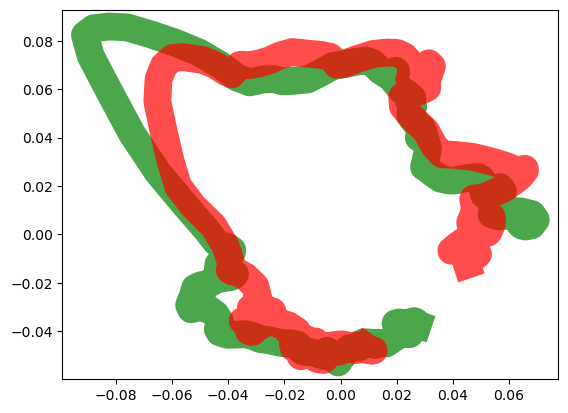

E:/CK-87-data/2023-03-22/
0.18010418580031048


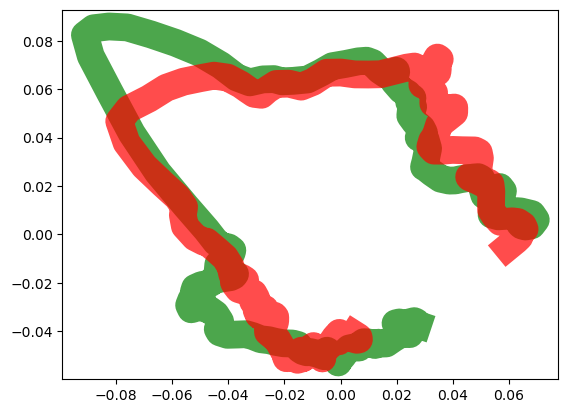

E:/CK-87-data/2023-03-23/
0.15110719482820328


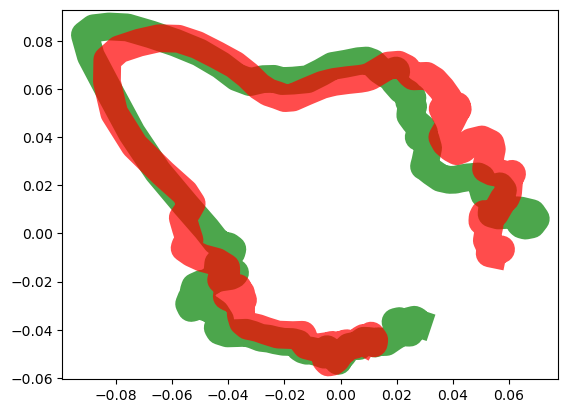

E:/CK-87-data/2023-03-24/
0.10729542302489503


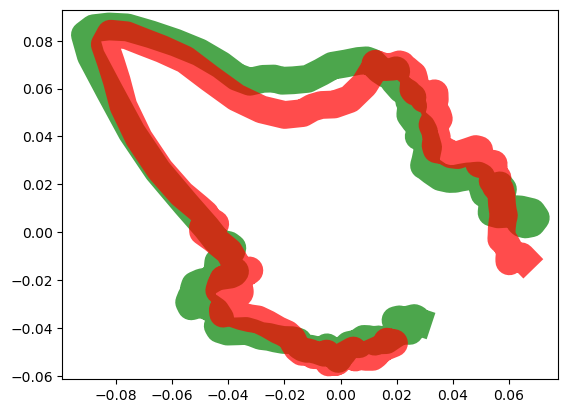

E:/CK-87-data/2023-03-25/
0.07657283446825594


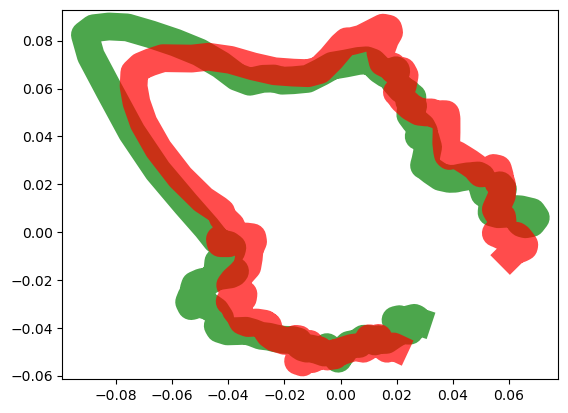

E:/CK-87-data/2023-03-26/
0.09750066174714714


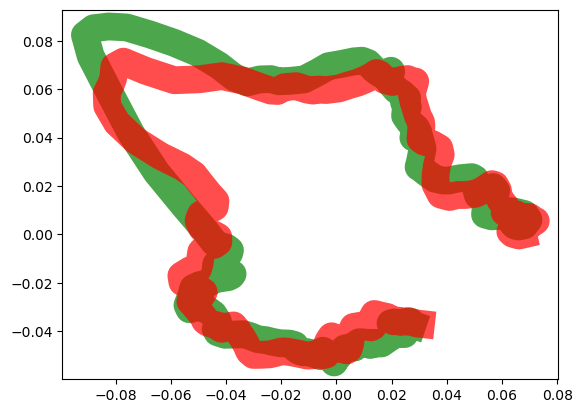

E:/CK-87-data/2023-03-28/
0.06679831870957617


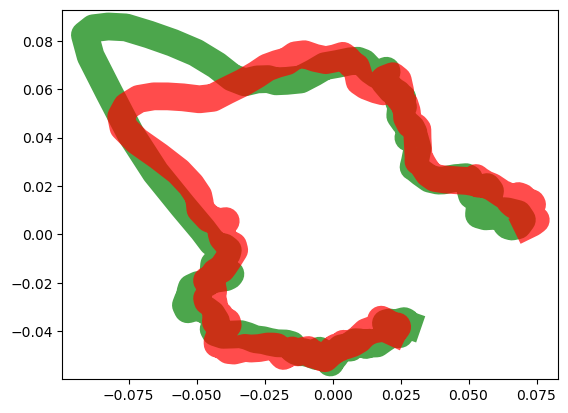

E:/CK-87-data/2023-03-30/
0.07831098865599381


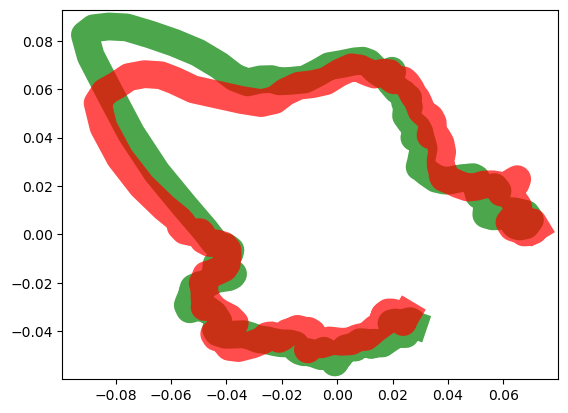

E:/CK-87-data/2023-03-31/
0.06912073766233251


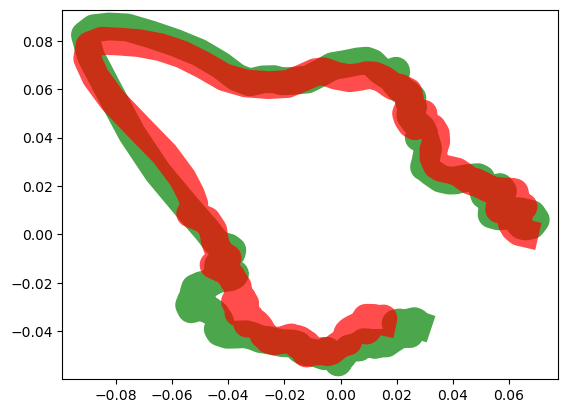

E:/CK-87-data/2023-04-01/
0.07602901097886805


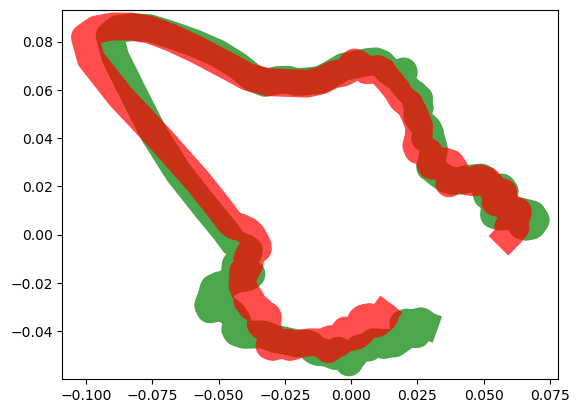

E:/CK-87-data/2023-04-03/
0.08078893464419


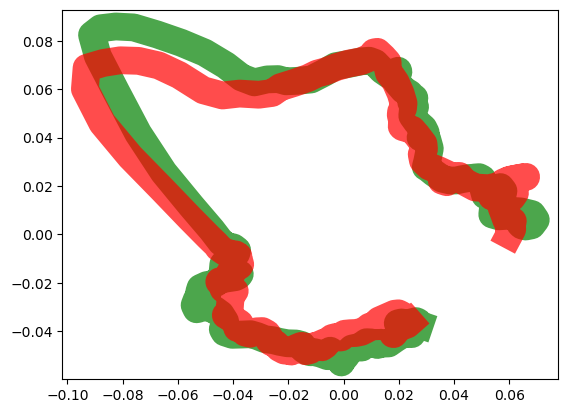

E:/CK-87-data/2023-04-04/
0.08129515250508867


In [36]:
Path = ['E:/CK-87-data/2023-03-21/','E:/CK-87-data/2023-03-22/','E:/CK-87-data/2023-03-23/',
        'E:/CK-87-data/2023-03-24/','E:/CK-87-data/2023-03-25/','E:/CK-87-data/2023-03-26/',
        'E:/CK-87-data/2023-03-28/','E:/CK-87-data/2023-03-30/','E:/CK-87-data/2023-03-31/',
        'E:/CK-87-data/2023-04-01/','E:/CK-87-data/2023-04-03/','E:/CK-87-data/2023-04-04/']
File = ['2023-03-21_matlab.mat','2023-03-22_matlab.mat','2023-03-23_matlab.mat','2023-03-24_matlab.mat'
             ,'2023-03-25_matlab.mat','2023-03-26_matlab.mat','2023-03-28_matlab.mat','2023-03-30_matlab.mat'
             ,'2023-03-31_matlab.mat','2023-04-01_matlab.mat','2023-04-03_matlab.mat','2023-04-04_matlab.mat']
i=0
for path, file in zip(Path, File):
    i += 1
    # Generate neural data
    Trace_Data_file = path+file
    Trace_Data = scipy.io.loadmat(Trace_Data_file)['trace']
    Trial_idx_file = path+'Trial_idx1.mat'
    Trial_idx = scipy.io.loadmat(Trial_idx_file)['Trial_idx1']
    door_open = Trial_idx[:,1]

    Behav_file = path+'behav_score.xlsx'
    behav_scores = pandas.read_excel(Behav_file, header=None)[0].values
    
    Deconvolved_Data = scipy.io.loadmat(Trace_Data_file)['s_diff']
    
    continuous_data, door_open_index = generate_continuous_data(Deconvolved_Data, door_open, [0,len(door_open)-1], [100,200])
        
    
    # Smooth
    continuous_data = gaussian_filter1d(continuous_data, 1, axis = 1)
    
    embedding = PCA(continuous_data, door_open_index, 10)
    
    all_trials_embedding = []
    for e in door_open_index:
        single_trial_embedding = embedding[e-pre:e+post]
        all_trials_embedding.append(single_trial_embedding)
    
    trial_averaged_embedding = np.average(all_trials_embedding,axis=0)
    
    mtx1,mtx2, disparity = scipy.spatial.procrustes(trial_averaged_template, trial_averaged_embedding)
    plt.plot(mtx1[:,0],mtx1[:,1],linewidth=20,alpha=0.7,c='green')
    plt.plot(mtx2[:,0],mtx2[:,1],linewidth=20,alpha=0.7,c='red')
    plt.show()
    print(path)
    print(disparity)